## Sentiment Analysis

### Problem Statement
#### Build a sentiment analysis model to classify customer reviews from Amazon into positive, negative, or neutral sentiments, and deploy it using Streamlit, or Flask.

### 01. Exploratory Data Analysis (EDA)

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from PIL import Image

# pip install wordcloud
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import nltk
# nltk.download('punkt_tab')
# nltk.download('stopwords')
# nltk.download('wordnet')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer

#### Load the Dataset

In [4]:
df= pd.read_excel("dataset.xlsx",sheet_name='Sheet1')
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [5]:
print("Dataset Shape:",df.shape)
df.info()

Dataset Shape: (1440, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


#### Check Null and Duplicate values

In [6]:
# Missing values
df.isnull().sum()

title     0
rating    0
body      0
dtype: int64

In [7]:
# Duplicate rows
print(df.duplicated().sum())

0


In [8]:
# Rating distribution
print(df["rating"].value_counts().sort_index())

rating
1    386
2    126
3    199
4    310
5    419
Name: count, dtype: int64


#### Creating sentiment labels

In [9]:
def rating_to_sentiment(rating):
    if rating<=2:
        return 'Negative'
    elif rating==3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['rating'].apply(rating_to_sentiment)

df[['rating','sentiment']].head()

,rating,sentiment
0,1,Negative
1,3,Neutral
2,4,Positive
3,1,Negative
4,1,Negative


In [10]:
print(df['sentiment'].value_counts())
print(df["sentiment"].value_counts(normalize=True) * 100)

sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64
sentiment
Positive    50.625000
Negative    35.555556
Neutral     13.819444
Name: proportion, dtype: float64


#### Combining title and review text

In [11]:
df["review"] = df['title'].astype(str)+ " "+ df['body'].astype(str)

df[['review','sentiment']].head()

,review,sentiment
0,Horrible product Very disappointed with the ov...,Negative
1,Camera quality is not like 48 megapixel Camera...,Neutral
2,"Overall Got the mobile on the launch date,Batt...",Positive
3,A big no from me 1. It doesn't work with 5.0GH...,Negative
4,Put your money somewhere else Not worth buying...,Negative


#### Explore rating and sentiment distribution 

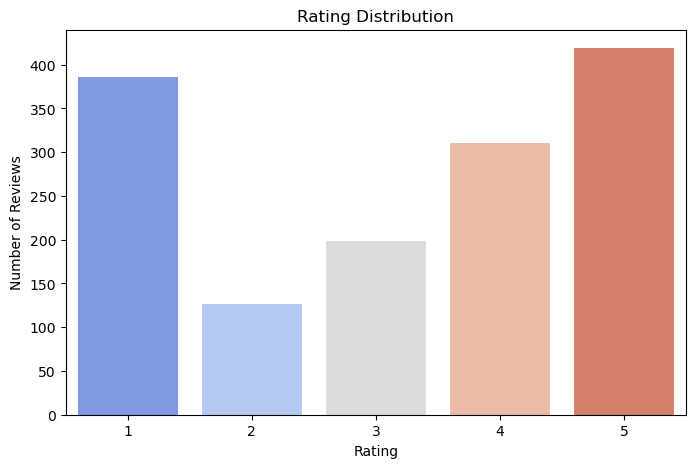

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='rating',palette='coolwarm',legend=False)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

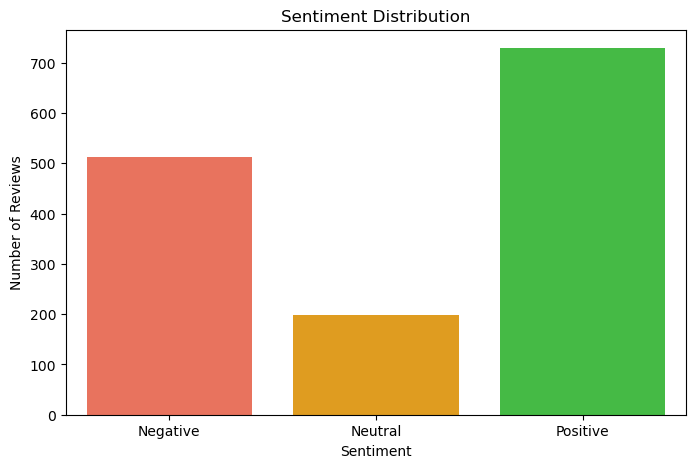

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="sentiment",
    order=["Negative", "Neutral", "Positive"],
    hue="sentiment",
    palette={"Negative": "tomato", "Neutral": "orange", "Positive": "#32CD32"},
    legend=False
)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

#### Review length analysis

In [14]:
df["review_length"] = df["review"].apply(len)
df["word_count"] = df["review"].apply(lambda text: len(text.split()))

df[["review_length", "word_count"]].describe().T

,count,mean,std,min,25%,50%,75%,max
review_length,1440.0,333.381944,229.116704,9.0,198.0,277.0,395.0,2536.0
word_count,1440.0,58.257639,39.896874,2.0,34.0,49.0,70.0,391.0


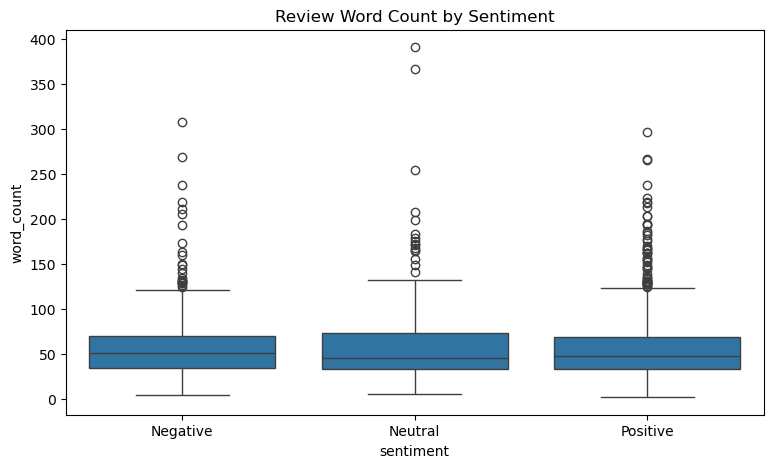

In [15]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="sentiment", y="word_count",
            order=["Negative", "Neutral", "Positive"])
plt.title("Review Word Count by Sentiment")
plt.show()

In [16]:
# Viewing examples from each sentiment
for sentiment in ["Negative", "Neutral", "Positive"]:
    print(f"\n--- {sentiment} Reviews ---")
    display(df[df["sentiment"] == sentiment][["rating", "review"]].head(3))


--- Negative Reviews ---


,rating,review
0,1,Horrible product Very disappointed with the ov...
3,1,A big no from me 1. It doesn't work with 5.0GH...
4,1,Put your money somewhere else Not worth buying...



--- Neutral Reviews ---


,rating,review
1,3,Camera quality is not like 48 megapixel Camera...
23,3,"Not So impressive,okay okay.Little over price ..."
30,3,Good battery but average performance Pros:1. T...



--- Positive Reviews ---


,rating,review
2,4,"Overall Got the mobile on the launch date,Batt..."
14,5,Good one in this price segment. Just unboxed t...
19,5,Perfect phone with this price This is perfect ...


### 02. Preprocessing

#### Clean Text for modeling

In [17]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # remove URLs
    text = re.sub(r"[^a-z0-9\s]", " ", text)   # Keep letters, numbers, and spaces
    text = re.sub(r"\s+", " ", text).strip()     # remove extra spaces    
    return text

df["clean_review"] = df["review"].apply(clean_text)

df[["review", "clean_review"]].head()

,review,clean_review
0,Horrible product Very disappointed with the ov...,horrible product very disappointed with the ov...
1,Camera quality is not like 48 megapixel Camera...,camera quality is not like 48 megapixel camera...
2,"Overall Got the mobile on the launch date,Batt...",overall got the mobile on the launch date batt...
3,A big no from me 1. It doesn't work with 5.0GH...,a big no from me 1 it doesn t work with 5 0ghz...
4,Put your money somewhere else Not worth buying...,put your money somewhere else not worth buying...


In [18]:
stop_words = set(stopwords.words('english'))
negation_words = {"no", "not", "never", "neither", "dont", "nor"}
stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()

# Regex for important mobile specs
spec_pattern = re.compile(r"^\d+(mAh|hz|mp|gb|tb|w|inch|ghz|nm|fps|ppi|nits)$", re.IGNORECASE)

def preprocess_text(text):
    tokens = word_tokenize(text)
    cleaned_tokens = []

    for word in tokens:
        word_lower = word.lower()

        # Keep alphabetic words (lemmatized)
        if word.isalpha() and word_lower not in stop_words:
            cleaned_tokens.append(lemmatizer.lemmatize(word_lower))

        # Keep important specs (numbers + units)
        elif spec_pattern.match(word_lower):
            cleaned_tokens.append(word_lower)

        # Keep small rating numbers (like 1–10 stars)
        elif word.isdigit() and 1 <= int(word) <= 10:
            cleaned_tokens.append(word_lower)


        # Ignore other meaningless numbers
        else:
            continue

    return " ".join(cleaned_tokens)

df["cleaned_review"] = df["clean_review"].apply(preprocess_text)

In [19]:
# Remove empty reviews
df = df[df["cleaned_review"].str.len() > 0].copy()
print("Final dataset shape:", df.shape)

# check duplicates
print(df.duplicated().sum())

Final dataset shape: (1438, 9)
0


#### Create word clouds

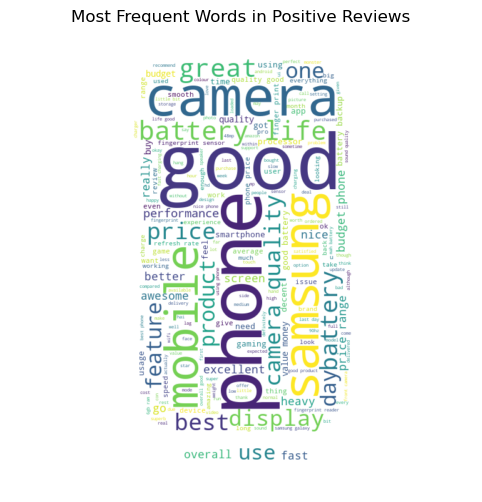

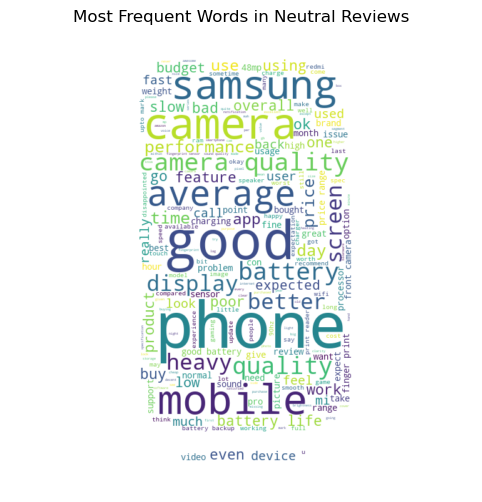

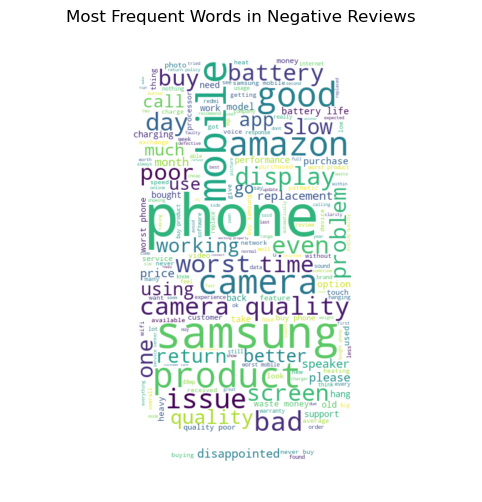

In [20]:
def show_wordcloud(sentiment):
    text = " ".join(df[df["sentiment"] == sentiment]["cleaned_review"])
    phone_mask = np.array(Image.open('smartphone.jpg'))
    
    wordcloud = WordCloud(
        width=900,
        height=450,
        background_color="white",
        colormap="viridis",
        mask=phone_mask
    ).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Most Frequent Words in {sentiment} Reviews")
    plt.show()

show_wordcloud("Positive")
show_wordcloud("Neutral")
show_wordcloud("Negative")


#### Label Encoding

In [21]:
X=df['cleaned_review']
y=df['sentiment']
X.head()

0    horrible product disappointed overall performa...
1    camera quality not like megapixel camera quali...
2    overall got mobile launch date battery must ap...
3    big no 1 work 5 0ghz wifi frequency 2 4ghz old...
4    put money somewhere else not worth buying faul...
Name: cleaned_review, dtype: object

In [22]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df["sentiment"])

print("Classes:", label_encoder.classes_)
print("Encoded labels:", y[:10])

Classes: ['Negative' 'Neutral' 'Positive']
Encoded labels: [0 1 2 0 0 0 0 0 0 0]


#### splitting data into training and testing data

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify= y)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1150
Testing samples: 288


In [24]:
df.to_csv("cleaned_sentiment_reviews.csv", index=False)

In [25]:
df1 = pd.read_csv("cleaned_sentiment_reviews.csv")
df1.head(3)

,title,rating,body,sentiment,review,review_length,word_count,clean_review,cleaned_review
0,Horrible product,1,Very disappointed with the overall performance...,Negative,Horrible product Very disappointed with the ov...,76,10,horrible product very disappointed with the ov...,horrible product disappointed overall performa...
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,Camera quality is not like 48 megapixel Camera...,61,11,camera quality is not like 48 megapixel camera...,camera quality not like megapixel camera quali...
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,"Overall Got the mobile on the launch date,Batt...",411,67,overall got the mobile on the launch date batt...,overall got mobile launch date battery must ap...


### 03. Feature Extraction

In [26]:
# Feature extraction using TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (1150, 5000)
Testing shape: (288, 5000)


In [27]:
import pandas as pd

# Step 1: Extract feature names from TF-IDF
feature_names = tfidf.get_feature_names_out()

# Step 2: Get vector for the first document
doc_vector = X_train_tfidf[0].toarray().flatten()

# Step 3: Pair feature names with their TF-IDF scores
doc_features = list(zip(feature_names, doc_vector))

# Step 4: Sort by score (descending) and take top 20
top_features = sorted(doc_features, key=lambda x: x[1], reverse=True)[:20]

# Step 5: Convert to DataFrame for table view
top_df = pd.DataFrame(top_features, columns=["Feature", "TF-IDF Score"])

print(top_df)

           Feature  TF-IDF Score
0           weight      0.277378
1           active      0.232685
2            state      0.232685
3              avg      0.224892
4   charge battery      0.224892
5      nice mobile      0.224892
6    within budget      0.224892
7           lasted      0.218524
8    mobile within      0.218524
9        bluetooth      0.208476
10     full charge      0.208476
11         hotspot      0.208476
12    working good      0.208476
13             min      0.194314
14         concern      0.191519
15           level      0.186521
16            full      0.148150
17            hour      0.145175
18          within      0.142435
19          charge      0.138689


### 04. Model Building

#### Importing Models 

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#### Create the models

In [29]:
# 1.Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)

# Naive_bayes
naive_bayes_model = MultinomialNB()

# SVM
svm_model = LinearSVC()

# Random Forest
random_forest_model = RandomForestClassifier(n_estimators=100,random_state=42)

#XGBOOST
xgboost_model = XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss')

In [30]:
# Train Logistic Regression
logistic_model.fit(X_train_tfidf, y_train)
y_pred_lr = logistic_model.predict(X_test_tfidf)


# Train Naive Bayes
naive_bayes_model.fit(X_train_tfidf, y_train)
y_pred_nb = naive_bayes_model.predict(X_test_tfidf)


# Train SVM
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)


# Train Random Forest
random_forest_model.fit(X_train_tfidf, y_train)
y_pred_rf = random_forest_model.predict(X_test_tfidf)


# Train XGBoost
xgboost_model.fit(X_train_tfidf, y_train)
y_pred_xgb = xgboost_model.predict(X_test_tfidf)


print("All 5 models trained and predictions generated successfully.")

All 5 models trained and predictions generated successfully.


#### Evaluating the Models 

In [31]:
from sklearn.metrics import (confusion_matrix,classification_report,accuracy_score,precision_score,recall_score,f1_score)

In [32]:
def eval_clf(y, yhat):

    # Confusion Matrix
    cm = confusion_matrix(y, yhat)

    plt.figure(figsize=(5, 4))

    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
        xticklabels=['Negative', 'Neutral', 'Positive'],
        yticklabels=['Negative', 'Neutral', 'Positive'])

    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')

    plt.show()


    # Classification Report
    print("Classification Report:")
    print(classification_report(y,yhat,target_names=['Negative', 'Neutral', 'Positive']))


    # Evaluation Metrics
    precision = precision_score(y, yhat, average='weighted')
    recall = recall_score(y, yhat, average='weighted')
    accuracy = accuracy_score(y, yhat)
    f1 = f1_score(y, yhat, average='weighted')


    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"F1-Score:  {f1:.4f}")

Evaluation For Logistic Regression


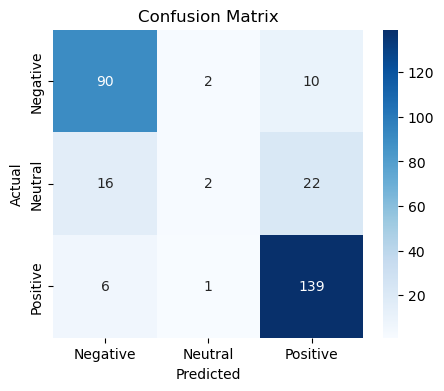

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.88      0.84       102
     Neutral       0.40      0.05      0.09        40
    Positive       0.81      0.95      0.88       146

    accuracy                           0.80       288
   macro avg       0.67      0.63      0.60       288
weighted avg       0.75      0.80      0.75       288

Precision: 0.7522
Recall:    0.8021
Accuracy:  0.8021
F1-Score:  0.7548


In [33]:
print(f'Evaluation For Logistic Regression')
eval_clf(y_test, y_pred_lr)

Evaluation For Logistic Regression


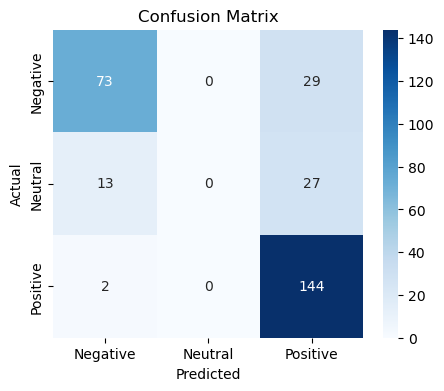

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.72      0.77       102
     Neutral       0.00      0.00      0.00        40
    Positive       0.72      0.99      0.83       146

    accuracy                           0.75       288
   macro avg       0.52      0.57      0.53       288
weighted avg       0.66      0.75      0.69       288

Precision: 0.6588
Recall:    0.7535
Accuracy:  0.7535
F1-Score:  0.6941


In [34]:
print(f'Evaluation For Logistic Regression')
eval_clf(y_test, y_pred_nb)

Evaluation For Logistic Regression


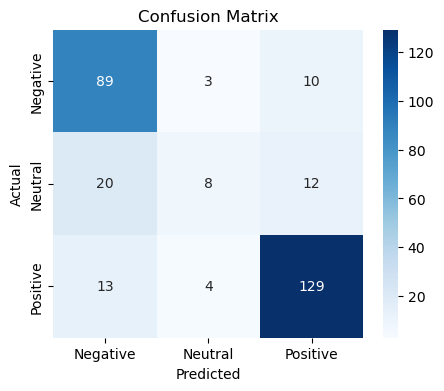

Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.87      0.79       102
     Neutral       0.53      0.20      0.29        40
    Positive       0.85      0.88      0.87       146

    accuracy                           0.78       288
   macro avg       0.71      0.65      0.65       288
weighted avg       0.77      0.78      0.76       288

Precision: 0.7655
Recall:    0.7847
Accuracy:  0.7847
F1-Score:  0.7622


In [35]:
print(f'Evaluation For Logistic Regression')
eval_clf(y_test, y_pred_svm)

Evaluation For Logistic Regression


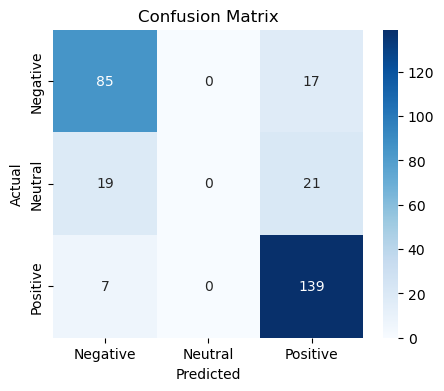

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.83      0.80       102
     Neutral       0.00      0.00      0.00        40
    Positive       0.79      0.95      0.86       146

    accuracy                           0.78       288
   macro avg       0.52      0.60      0.55       288
weighted avg       0.67      0.78      0.72       288

Precision: 0.6693
Recall:    0.7778
Accuracy:  0.7778
F1-Score:  0.7190


In [36]:
print(f'Evaluation For Logistic Regression')
eval_clf(y_test, y_pred_rf)

Evaluation For Logistic Regression


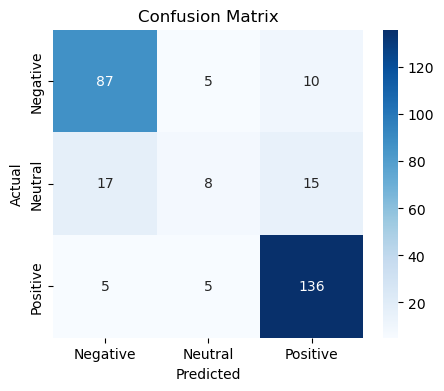

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.85      0.82       102
     Neutral       0.44      0.20      0.28        40
    Positive       0.84      0.93      0.89       146

    accuracy                           0.80       288
   macro avg       0.70      0.66      0.66       288
weighted avg       0.77      0.80      0.78       288

Precision: 0.7726
Recall:    0.8021
Accuracy:  0.8021
F1-Score:  0.7795


In [37]:
print(f'Evaluation For Logistic Regression')
eval_clf(y_test, y_pred_xgb)

In [38]:
predictions = {
    "Logistic Regression": y_pred_lr,
    "Naive Bayes": y_pred_nb,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

results = []

for model_name, y_pred in predictions.items():

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.802083   0.752231  0.802083  0.754819
1          Naive Bayes  0.753472   0.658797  0.753472  0.694114
2                  SVM  0.784722   0.765527  0.784722  0.762216
3        Random Forest  0.777778   0.669318  0.777778  0.718986
4              XGBoost  0.802083   0.772638  0.802083  0.779525


In [42]:
def predict_sentiment(review):

    # Preprocess the new review
    cleaned_review = preprocess_text(review)

    # Convert text into TF-IDF
    review_tfidf = tfidf.transform([cleaned_review])

    # Predict using original XGBoost model
    prediction = xgboost_model.predict(review_tfidf)[0]

    # Convert numerical label back to sentiment
    sentiment = label_encoder.inverse_transform([prediction])[0]

    return sentiment

In [43]:
review = "Horrible product Very disappointed with the overall performance from Samsung"

result = predict_sentiment(review)

print("Review:", review)
print("Predicted Sentiment:", result)

Review: Horrible product Very disappointed with the overall performance from Samsung
Predicted Sentiment: Negative


In [44]:
reviews = [
    "The product is excellent and I love it.",
    "The product is worst and completely useless.",
    "The product is okay, nothing special and its a average."
]

for review in reviews:
    print(review)
    print("Prediction:", predict_sentiment(review))
    print()

The product is excellent and I love it.
Prediction: Positive

The product is worst and completely useless.
Prediction: Negative

The product is okay, nothing special and its a average.
Prediction: Neutral



In [45]:
for i in range(10):

    review = X_test.iloc[i]

    prediction = xgboost_model.predict(
        tfidf.transform([review])
    )[0]

    sentiment = label_encoder.inverse_transform([prediction])[0]

    print("Review:", review)
    print("Actual:", label_encoder.inverse_transform([y_test[i]])[0])
    print("Predicted:", sentiment)
    print("-" * 100)

Review: receiving annoy ad full screen often disappointed purchase get annoying ad often know remove even tried every method remove please help get rid know bought sale problem happening not solve recommend every one not buy phone
Actual: Negative
Predicted: Negative
----------------------------------------------------------------------------------------------------
Review: good phone light weight lovely colour ui good camera setting changed default picture quality set 5mp software update could change right mp
Actual: Positive
Predicted: Positive
----------------------------------------------------------------------------------------------------
Review: budget phone normal user not gaming decent phone not meant heavy tasking screen decent samsung ui working good sound decent charging time little bit higher due huge battery approx 3 hour charging wire small camera good fingerprint scanner decent phone little bit heavy easy handle phone normal user not gaming sometime phone feel exynos n

In [47]:
import joblib

joblib.dump(logistic_model, "logistic_model.pkl")
joblib.dump(naive_bayes_model, "naive_bayes_model.pkl")
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(random_forest_model, "random_forest_model.pkl")
joblib.dump(xgboost_model, "xgboost_model.pkl")

joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("All models and preprocessing files saved successfully!")

All models and preprocessing files saved successfully!
